In [1]:
import torch
import torchphysics as tp
X = tp.spaces.R1('x')
Y = tp.spaces.R1('y')
U = tp.spaces.R1('u')
V = tp.spaces.R1('v')
URMS = tp.spaces.R1('urms')
VRMS = tp.spaces.R1('vrms')
UV=tp.spaces.R1('uv')
P=tp.spaces.R1('p')

/net/istmhome/users/hi224/Dokumente/Python/TorchPhysics/TP/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd
import numpy as np

In [3]:
class Turbulent_Data(torch.utils.data.Dataset):
    def __init__(self,data_DF,x_list,y_list,Nsamples=30):
        self.x_train=data_DF[x_list].values
        self.y_train=data_DF[y_list].values
        self.N_iter=Nsamples
        self.ids=random.sample(range(len(data_DF)),self.N_iter)
        self.counter=0
    def __len__(self):
        return len(self.y_train)

    def __getitem__(self,idx):
        if idx>self.N_iter:
            raise StopIteration
        #return self.x_train[idx] , self.y_train[idx]
        #print(torch.as_tensor([self.x_train[idx]]).shape)
        if self.counter>(self.N_iter):
            self.counter=0
            self.ids=random.sample(range(len(self.x_train)),self.N_iter)
        idx_local=self.ids[idx]
        #idx_local=idx
        P_xtrain=tp.spaces.Points([self.x_train[idx_local]],X*Y,dtype=torch.float32)
        P_ytrain=tp.spaces.Points([self.y_train[idx_local]],U*V*URMS*VRMS*UV,dtype=torch.float32)
        self.counter+=1
        return P_xtrain,P_ytrain

In [4]:
class Turbulent_Data_local(torch.utils.data.Dataset):
    def __init__(self,data_DF,x_list,y_list,Nsamples=451):
        self.x_positions=data_DF["x"].unique()
        self.data=data_DF
        #self.x_train=torch.tensor(x_train,dtype=torch.float32)
        #self.y_train=torch.tensor(y_train,dtype=torch.float32)
        #self.x_train=tp.spaces.Points(self.x_train,X*Y)
        #self.y_train=tp.spaces.Points(self.y_train,U*V)
        self.N_iter=Nsamples
        self.local=random.sample(self.x_positions,1)
        self.x_train=data_DF[data_DF["x"]==self.local][x_list].values
        self.y_train=data_DF[data_DF["x"]==self.local][y_list].values
    def __len__(self):
        return len(self.y_train)

    def __getitem__(self,idx):
        if idx>self.N_iter:
            raise StopIteration
        #return self.x_train[idx] , self.y_train[idx]
        #print(torch.as_tensor([self.x_train[idx]]).shape)
        #idx_local=np.random.randint(0,len(self.y_train)-1)
        idx_local=idx
        P_xtrain=tp.spaces.Points([self.x_train[idx_local]],X*Y,dtype=torch.float32)
        P_ytrain=tp.spaces.Points([self.y_train[idx_local]],U*V*URMS*VRMS*UV,dtype=torch.float32)
        return P_xtrain,P_ytrain

In [5]:
class Ho_Turbulent_Data(torch.utils.data.Dataset):
    def __init__(self,data_DF,x_list,y_list,horizon_sampler,Nsamples=30):
        self.x_train=data_DF[x_list].values
        self.y_train=data_DF[y_list].values
        self.sampler=horizon_sampler
        self.N_iter=Nsamples
        #self.x_train=torch.tensor(x_train,dtype=torch.float32)
        #self.y_train=torch.tensor(y_train,dtype=torch.float32)
        #self.x_train=tp.spaces.Points(self.x_train,X*Y)
        #self.y_train=tp.spaces.Points(self.y_train,U*V)
    def __len__(self):
        return len(self.y_train)

    def __getitem__(self,idx):
        if idx>self.N_iter:
            raise StopIteration
        x_horizon= self.sampler.sample_points(device="cpu")
        x_horizon,_=x_horizon.track_coord_gradients()
        x_horizon=x_horizon["x"].detach().numpy()
        #print(x_horizon)
        idx_local=np.random.randint(0,len(self.y_train)-1)
        y_new=np.broadcast_to(self.x_train[idx_local],(x_horizon.shape[0],self.x_train[idx_local].shape[0]))
        target_new=np.broadcast_to(self.y_train[idx_local],(x_horizon.shape[0],self.y_train[idx_local].shape[0]))
        X_points = np.concatenate((x_horizon,y_new),axis=1)
        P_xtrain=tp.spaces.Points([X_points],X*Y,dtype=torch.float32)
        P_ytrain=tp.spaces.Points([target_new],U*V*URMS*VRMS*UV,dtype=torch.float32)
        return P_xtrain,P_ytrain

In [6]:
class Rn_Turbulent_Data(torch.utils.data.Dataset):
    def __init__(self,data_DF,x_list,y_list,max_it):
        self.x_train=data_DF[x_list].values
        self.y_train=data_DF[y_list].values
        self.length=min(max_it,len(self.y_train))
        #self.x_train=torch.tensor(x_train,dtype=torch.float32)
        #self.y_train=torch.tensor(y_train,dtype=torch.float32)
        #self.x_train=tp.spaces.Points(self.x_train,X*Y)
        #self.y_train=tp.spaces.Points(self.y_train,U*V)
    def __len__(self):
        return self.length

    def __getitem__(self,idx):
        #return self.x_train[idx] , self.y_train[idx]
        #print(torch.as_tensor([self.x_train[idx]]).shape)
        id_random=random.randint(0,len(self.y_train))
        P_xtrain=tp.spaces.Points([self.x_train[id_random]],X*Y,dtype=torch.float32)
        P_ytrain=tp.spaces.Points([self.y_train[id_random]],U*V*URMS*VRMS*UV,dtype=torch.float32)
        return P_xtrain,P_ytrain

In [7]:
DF_Data=pd.read_csv("Data/Flow_3d_2289_6_C.csv")

In [8]:
DF_Data["V"]=DF_Data["V"]*50

In [9]:
DF_Data["x"].unique()

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  , 1.05,
       1.1 , 1.15, 1.2 , 1.25, 1.3 , 1.35, 1.4 , 1.45, 1.5 , 1.55, 1.6 ,
       1.65, 1.7 , 1.75, 1.8 , 1.85, 1.9 , 1.95, 2.  , 2.05, 2.1 , 2.15,
       2.2 , 2.25, 2.3 , 2.35, 2.4 , 2.45, 2.5 , 2.55, 2.6 , 2.65, 2.7 ,
       2.75, 2.8 , 2.85, 2.9 , 2.95, 3.  , 3.05, 3.1 , 3.15, 3.2 , 3.25,
       3.3 , 3.35, 3.4 , 3.45, 3.5 , 3.55])

In [10]:
import random
def Augment_1D_data(DF,Nsampler,L_x):
    DF_out=DF[0:0]
    for _ in range(Nsampler):
        Ny=random.randint(0, len(DF)-1)
        DF_temp=DF.iloc[[Ny]]
        DF_temp["x"]=random.uniform(0,L_x)
        DF_out=pd.concat([DF_out,DF_temp],ignore_index=True)
    return DF_out

        

In [11]:
torch.cuda.device_count()

0

In [12]:
X_interval = tp.domains.Interval(X, 0, 3.6) # <-add the bounds of the Interval (0, 2)
Y_interval = tp.domains.Interval(Y, 0, 2.0)
Sim_domain = X_interval*Y_interval

Y_interval_sub_low=tp.domains.Interval(Y, 0, 0.08)
Sim_domain_sub_low=X_interval*Y_interval_sub_low
Y_interval_sub_up=tp.domains.Interval(Y, 2-0.08, 2)
Sim_domain_sub_up=X_interval*Y_interval_sub_up

In [13]:
#DF_out=Augment_1D_data(DF_Data,8000,2.0)
ho_sampler = tp.samplers.RandomUniformSampler(X_interval, n_points=200)


In [14]:

bound_sampler_low = tp.samplers.RandomUniformSampler(Y_interval.boundary_left*X_interval, n_points=250)

bound_sampler_up = tp.samplers.RandomUniformSampler(X_interval*Y_interval.boundary, n_points=500)


In [15]:
DF_DIST=pd.read_csv("Data/DIST_2289.csv")

In [16]:
x_corr=DF_DIST["x"].to_numpy()
x_corr=torch.tensor(x_corr,requires_grad=False)
dist=DF_DIST["dist"].to_numpy()
dist=torch.tensor(dist,requires_grad=False)

In [17]:
DF_Data

,x,y,U,V,urms,vrms,uv
0,0.00,0.000000,2.600700e-15,-1.846450e-16,2.140100e-13,8.048000e-16,-1.577900e-29
1,0.00,0.002436,4.322700e-06,1.436500e-04,3.735500e-02,2.134900e-03,-2.881200e-05
2,0.00,0.009732,1.252400e-05,1.089550e-03,5.116400e-02,1.570100e-02,-3.013900e-04
3,0.00,0.021852,4.766400e-05,4.239800e-03,5.965900e-02,4.623800e-02,-1.137100e-03
4,0.00,0.038738,3.565800e-04,4.114250e-03,2.368600e-01,1.437300e-01,-6.545700e-03
...,...,...,...,...,...,...,...
3307,3.55,1.961300,9.051400e-05,-2.919550e-02,2.969400e-01,1.072500e-01,1.196500e-03
3308,3.55,1.978100,1.233600e-04,-1.024350e-02,5.276000e-02,3.602400e-02,1.729700e-04
3309,3.55,1.990300,1.150600e-04,-3.723400e-03,4.650700e-02,1.312700e-02,9.688800e-05
3310,3.55,1.997600,1.133100e-04,-6.435500e-04,3.697200e-02,2.175200e-03,1.250000e-05


In [18]:
def pop_data_in_IBM(DF,dist,x_corr):
    row=0
    DF_new=DF
    while row<=len(DF)-1:
        position_r=sum(x_corr<DF_new["x"][row])-1
        position_l=position_r-1
        height=dist[position_l]+(dist[position_r]-dist[position_l])*(DF_new["x"][row]-x_corr[position_l])/(x_corr[position_r]-x_corr[position_l])
        if (DF_new["y"][row]<=height) or (DF_new["y"][row]>=2-height):
            DF_new.iloc[row][["U","V","urms","vrms","uv"]]=0
            #DF_new.drop(row)
        row+=1
    DF_new.reset_index()
    return DF_new

In [19]:
#DF_processed=pop_data_in_IBM(DF_Data,dist,x_corr)
DF_processed=DF_Data

In [20]:
DF_processed

,x,y,U,V,urms,vrms,uv
0,0.00,0.000000,2.600700e-15,-1.846450e-16,2.140100e-13,8.048000e-16,-1.577900e-29
1,0.00,0.002436,4.322700e-06,1.436500e-04,3.735500e-02,2.134900e-03,-2.881200e-05
2,0.00,0.009732,1.252400e-05,1.089550e-03,5.116400e-02,1.570100e-02,-3.013900e-04
3,0.00,0.021852,4.766400e-05,4.239800e-03,5.965900e-02,4.623800e-02,-1.137100e-03
4,0.00,0.038738,3.565800e-04,4.114250e-03,2.368600e-01,1.437300e-01,-6.545700e-03
...,...,...,...,...,...,...,...
3307,3.55,1.961300,9.051400e-05,-2.919550e-02,2.969400e-01,1.072500e-01,1.196500e-03
3308,3.55,1.978100,1.233600e-04,-1.024350e-02,5.276000e-02,3.602400e-02,1.729700e-04
3309,3.55,1.990300,1.150600e-04,-3.723400e-03,4.650700e-02,1.312700e-02,9.688800e-05
3310,3.55,1.997600,1.133100e-04,-6.435500e-04,3.697200e-02,2.175200e-03,1.250000e-05


In [21]:
dataset_turbulent=Turbulent_Data(DF_processed,["x","y"],["U","V","urms","vrms","uv"],len(DF_processed))

In [22]:
def IBM_irr_filter_up(x,y):
    position_r=np.array([sum(x_corr<x_i)-1 for x_i in x])
    #position_r=sum(x_corr<x)
    position_l=position_r-1
    x_new=torch.transpose(x,1,0)[0]
    height=dist[position_l]+(dist[position_r]-dist[position_l])*(x_new-x_corr[position_l])/(x_corr[position_r]-x_corr[position_l])
    return (y[...,0]>=2-height)   
def IBM_irr_filter_low(x,y):
    position_r=np.array([sum(x_corr<x_i)-1 for x_i in x])
    #position_r=sum(x_corr<x)
    position_l=position_r-1
    x_new=torch.transpose(x,1,0)[0]
    height=dist[position_l]+(dist[position_r]-dist[position_l])*(x_new-x_corr[position_l])/(x_corr[position_r]-x_corr[position_l])
    return (y[...,0]<=height)
IBM_sampler_irr_low = tp.samplers.RandomUniformSampler(Sim_domain_sub_low,n_points=1000,filter_fn=IBM_irr_filter_low).make_static(resample_interval=2000)
IBM_sampler_irr_up = tp.samplers.RandomUniformSampler(Sim_domain_sub_up,n_points=1000,filter_fn=IBM_irr_filter_up).make_static(resample_interval=2000)

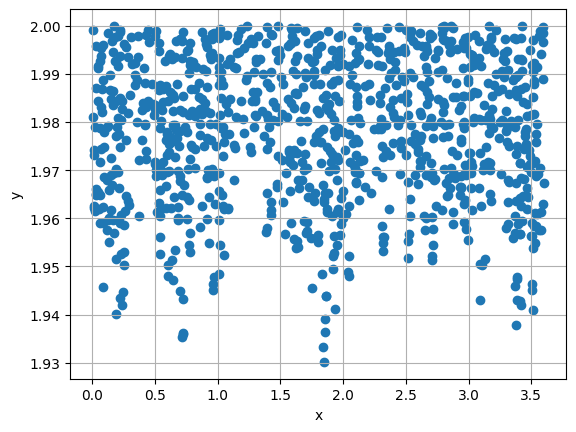

In [23]:
Omega_sampler = tp.samplers.RandomUniformSampler(Sim_domain, n_points=500)
plot           = tp.utils.scatter(X*Y, IBM_sampler_irr_up)

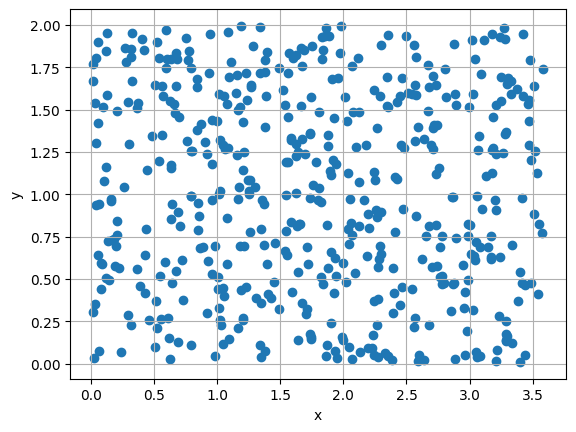

In [24]:
Omega_sampler = tp.samplers.RandomUniformSampler(Sim_domain, n_points=500)
plot           = tp.utils.scatter(X*Y, Omega_sampler)

In [25]:
def IBM_filter(x,y):
    return y[...,0]<=torch.sin(x[...,0]*np.pi*2)*0.1    
IBM_sampler_ = tp.samplers.RandomUniformSampler(Sim_domain,n_points=1000,filter_fn=IBM_filter)

In [26]:
def IBM_filter_2(y):
    return (y[...,0]<0)&(y[...,0]>-0.1)
    
IBM_sampler_2 = tp.samplers.RandomUniformSampler(Sim_domain,n_points=1000,filter_fn=IBM_filter_2)

In [27]:
def Inner_filter(y):
    position_r=np.array([sum(x_corr<x_i)-1 for x_i in x])
    #position_r=sum(x_corr<x)
    position_l=position_r-1
    x_new=torch.transpose(x,1,0)[0]
    height=dist[position_l]+(dist[position_r]-dist[position_l])*(x_new-x_corr[position_l])/(x_corr[position_r]-x_corr[position_l])
    return (y[...,0]>height) &(y[...,0]<2-height)   
inner_sampler = tp.samplers.RandomUniformSampler(Sim_domain, n_points=5000).make_static(resample_interval=2000)#,filter_fn=Inner_filter)

In [28]:
def self_sin(input):
    return input.sin()
def self_cos(input):
    return input.cos()

In [29]:
import torch.nn as nn
import torch.nn.functional as F
torch.manual_seed(seed=42)
class FCN_model_Fourier_Feature(nn.Module):
    def __init__(self,input_space,output_space,N_features,sigma_1=1,sigma_2=20):
        super().__init__()
        self.W_1 = torch.tensor(torch.randn(input_space.dim , N_features //2, dtype=torch.float32) * sigma_1, dtype=torch.float32, requires_grad=False)
        self.W_2 = torch.tensor(torch.randn(input_space.dim , N_features //2, dtype=torch.float32) * sigma_2, dtype=torch.float32, requires_grad=False)
        self.register_buffer("selfW1", self.W_1, persistent=False)
        self.register_buffer("selfW2", self.W_2, persistent=False)
        self.output_space=output_space
        self.fc1_l=nn.Linear(in_features=N_features,out_features=150)
        self.fc2_l=nn.Linear(in_features=150,out_features=150)
        self.fc3_l=nn.Linear(in_features=150,out_features=150)
        self.fc4_l=nn.Linear(in_features=150,out_features=150)
        self.fc5_l=nn.Linear(in_features=150,out_features=150)
        self.fc6_l=nn.Linear(in_features=150,out_features=150)
        self.fc7_l=nn.Linear(in_features=150,out_features=150)
        ###
        self.fc1_r=nn.Linear(in_features=N_features,out_features=150)
        self.fc2_r=nn.Linear(in_features=150,out_features=150)
        self.fc3_r=nn.Linear(in_features=150,out_features=150)
        self.fc4_r=nn.Linear(in_features=150,out_features=150)
        self.fc5_r=nn.Linear(in_features=150,out_features=150)
        self.fc6_r=nn.Linear(in_features=150,out_features=150)
        self.fc7_r=nn.Linear(in_features=150,out_features=150)
        
        self.out=nn.Linear(in_features=N_features,out_features=output_space.dim)
    def forward(self,t):
        t_1=torch.concat((self_sin(torch.matmul(t,self.W_1)),self_cos(torch.matmul(t,self.W_1))),1)
        t_1=F.tanh(self.fc1_l(t_1))
        t_1=F.tanh(self.fc2_l(t_1))
        t_1=F.tanh(self.fc2_l(t_1))
        t_1=F.tanh(self.fc3_l(t_1))
        t_1=F.tanh(self.fc4_l(t_1))
        t_1=F.tanh(self.fc5_l(t_1))
        t_1=F.tanh(self.fc6_l(t_1))
        t_1=F.tanh(self.fc7_l(t_1))
        t_2=torch.concat((self_sin(torch.matmul(t,self.W_2)),self_cos(torch.matmul(t,self.W_2))),1)
        t_2=F.tanh(self.fc1_r(t_2))
        t_2=F.tanh(self.fc2_r(t_2))
        t_2=F.tanh(self.fc2_r(t_2))
        t_2=F.tanh(self.fc3_r(t_2))
        t_2=F.tanh(self.fc4_r(t_2))
        t_2=F.tanh(self.fc5_r(t_2))
        t_2=F.tanh(self.fc6_r(t_2))
        t_2=F.tanh(self.fc7_r(t_2))
        t=torch.concat((t_1,t_2),1)
        t=self.out(t)
        return tp.problem.spaces.Points(t, self.output_space)
        
model=FCN_model_Fourier_Feature(input_space=X*Y,output_space=U*V*URMS*VRMS*UV*P,N_features=300)

/tmp/ipykernel_1049338/1864652451.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.W_1 = torch.tensor(torch.randn(input_space.dim , N_features //2, dtype=torch.float32) * sigma_1, dtype=torch.float32, requires_grad=False)
/tmp/ipykernel_1049338/1864652451.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.W_2 = torch.tensor(torch.randn(input_space.dim , N_features //2, dtype=torch.float32) * sigma_2, dtype=torch.float32, requires_grad=False)


In [30]:

class self_Sin(torch.nn.Module):

  def forward(self, x):
    return torch.sin(x)
#model = tp.models.FCN(input_space=X*Y, output_space=U*V*URMS*VRMS*UV*P, hidden=(100,100,100,100,100,100,100),activations=tp.models.Sinus())#######Activation????

In [31]:
data_cond = tp.conditions.DataCondition(model, dataset_turbulent, norm=2.0,root=1.0,weight=1000,use_full_dataset=True,name='Data')

In [32]:
inte_sampler = tp.samplers.RandomUniformSampler(X_interval.boundary*Y_interval, n_points=250)
x_inlet_sampler=tp.samplers.RandomUniformSampler(X_interval*Y_interval,n_points=250)

In [33]:
def init_bulk(u_integral):
    return u_integral-1
pde_cond_bulk=tp.conditions.IntegroPINNCondition(model,x_inlet_sampler,init_bulk,inte_sampler, weight=1)

In [34]:
def pde_IBM(u,v):
    return torch.abs(u)+torch.abs(v)
pde_cond_IBM_up = tp.conditions.PINNCondition(model, IBM_sampler_irr_up, pde_IBM,weight=10,name='IBM_up')
pde_cond_IBM_low = tp.conditions.PINNCondition(model, IBM_sampler_irr_low, pde_IBM,weight=10,name='IBM_low')

In [35]:
def pde_IBM_uu(urms,vrms,uv,p):
    return torch.abs(urms)+torch.abs(vrms)+torch.abs(uv)+torch.abs(p)
pde_cond_IBM_up_uu = tp.conditions.PINNCondition(model, IBM_sampler_irr_up, pde_IBM_uu,weight=10,name='IBM_up_uu')
pde_cond_IBM_low_uu = tp.conditions.PINNCondition(model, IBM_sampler_irr_low, pde_IBM_uu,weight=10,name='IBM_low_uu')

In [36]:
def pde_IBM_2(u,v):
    return torch.sqrt(torch.square(u)+torch.square(v))
pde_cond_IBM_2 = tp.conditions.PINNCondition(model, IBM_sampler_2, pde_IBM_2,weight=10,name='IBM_2')

In [37]:
def pde_IBM_p(p):
    return p
pde_cond_IBM_p_up = tp.conditions.PINNCondition(model, IBM_sampler_irr_up, pde_IBM_p,weight=100,name='IBM_p_up')
pde_cond_IBM_p_low = tp.conditions.PINNCondition(model, IBM_sampler_irr_low, pde_IBM_p,weight=100,name='IBM_p_low')

In [38]:
def pde_mass(u,v,x,y):
    return tp.utils.grad(u,x)+tp.utils.grad(v/50,y)-0.0
pde_cond_mass = tp.conditions.PINNCondition(model, inner_sampler,pde_mass, weight=50,name='Conti')

In [39]:
def pde_residual_x(u,v, x, y,urms,vrms,uv,p):
    residual_momentum= u*tp.utils.grad(u,x)+ (v/50)*tp.utils.grad(u,y)+(-tp.utils.laplacian(u, x)-tp.utils.laplacian(u,y))/6000 - 0.02028418+tp.utils.grad(torch.square(urms/6),x)+tp.utils.grad(uv/60,y)+tp.utils.grad(p,x)
    return residual_momentum

pde_cond_x = tp.conditions.PINNCondition(model, inner_sampler, pde_residual_x, pde_IBM,weight=51,name='Momentum_x')

In [40]:
def pde_residual_y(u,v, x, y,urms,vrms,uv,p):
    residual_momentum= u*tp.utils.grad(v/50,x)+v/50*tp.utils.grad(v/50,y)+(-tp.utils.laplacian(v/50, x)-tp.utils.laplacian(v/50,y))/6000+tp.utils.grad(uv/60,x)+tp.utils.grad(torch.square(vrms/6),y)+tp.utils.grad(p,y)
    return residual_momentum

pde_cond_y = tp.conditions.PINNCondition(model, inner_sampler, pde_residual_y, pde_IBM,weight=50,name='Momentum_y')

In [41]:
def boundary_residual_x(u, x,y):
    return torch.square(u) - 0.0

boundary_cond_x = tp.conditions.PINNCondition(model, bound_sampler_up, boundary_residual_x, weight=1,name='noslip_x')

In [42]:
def boundary_residual_y(v, x,y):
    return torch.square(v) - 0.0

boundary_cond_y = tp.conditions.PINNCondition(model, bound_sampler_up, boundary_residual_y, weight=1,name='noslip_y')

In [43]:
def boundary_residual_uu(urms, x,y):
    return torch.square(urms) - 0.0

boundary_cond_uu = tp.conditions.PINNCondition(model, bound_sampler_up, boundary_residual_uu, weight=1,name='noslip_x_uu')

In [44]:
def boundary_residual_vv(vrms, x,y):
    return torch.square(vrms) - 0.0

boundary_cond_vv = tp.conditions.PINNCondition(model, bound_sampler_up, boundary_residual_vv, weight=1,name='noslip_x_vv')

In [45]:
def boundary_residual_uv(uv, x,y):
    return uv - 0.0

boundary_cond_uv = tp.conditions.PINNCondition(model, bound_sampler_up, boundary_residual_uv, weight=1,name='noslip_x_uv')

In [46]:

Periodic_sampler=tp.samplers.RandomUniformSampler(Y_interval,n_points=250)#,filter_fn=Inner_filter)

In [47]:
def periodic_residual_x(u_left,u_right):
    Periodic_condition= u_left - u_right
    return Periodic_condition
periodic_cond_x=tp.conditions.PeriodicCondition(model,X_interval,periodic_residual_x,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic_x')

In [48]:
def periodic_residual_y(v_left,v_right):
    Periodic_condition= v_left - v_right
    return Periodic_condition
periodic_cond_y=tp.conditions.PeriodicCondition(model,X_interval,periodic_residual_y,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic_y')

In [49]:
def periodic_residual_uu(urms_left,urms_right):
    Periodic_condition= urms_left - urms_right
    return Periodic_condition
periodic_cond_uu=tp.conditions.PeriodicCondition(model,X_interval,periodic_residual_uu,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic_uu')

In [50]:
def periodic_residual_vv(vrms_left,vrms_right):
    Periodic_condition= vrms_left - vrms_right
    return Periodic_condition
periodic_cond_vv=tp.conditions.PeriodicCondition(model,X_interval,periodic_residual_vv,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic_vv')

In [51]:
def periodic_residual_uv(uv_left,uv_right):
    Periodic_condition= uv_left - uv_right
    return Periodic_condition
periodic_cond_uv=tp.conditions.PeriodicCondition(model,X_interval,periodic_residual_uv,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic_uv')

In [52]:
def periodic_residual_p(p_left,p_right):
    Periodic_condition= p_left-p_right
    return Periodic_condition
periodic_cond_p=tp.conditions.PeriodicCondition(model,X_interval,periodic_residual_p,non_periodic_sampler=Periodic_sampler, weight=1,name='periodic_p')

In [53]:
bound_sampler_left = tp.samplers.RandomUniformSampler(X_interval.boundary_left*Y_interval, n_points=250)
def boundary_residual_p(p, x,y):
    return p

boundary_cond_p = tp.conditions.PINNCondition(model, bound_sampler_left, boundary_residual_p, weight=1,name='bound_p')

In [54]:
##Learning rate scheduling To-Do -- launch LR scheduling only after first training phase
optim = tp.OptimizerSetting(torch.optim.Adam, lr=0.001,scheduler_class=torch.optim.lr_scheduler.ReduceLROnPlateau,scheduler_args={"patience":1000,"factor":0.8,"verbose":True,"min_lr":0.000005},monitor_lr="train/loss")
#solver = tp.solver.Solver([pde_cond_IBM,pde_cond_mass,boundary_cond_x, pde_cond_x,periodic_cond_x,boundary_cond_y, pde_cond_y,periodic_cond_y], optimizer_setting=optim)
##loss terms scheduling
list_of_Losses=[pde_cond_IBM_up,#1000
                           pde_cond_IBM_low,
                           pde_cond_IBM_up_uu,#1000
                           pde_cond_IBM_low_uu,
                           #pde_cond_IBM_2,#1000
                            data_cond,
                           boundary_cond_x,#1000
                           boundary_cond_y,
                           boundary_cond_uu,#1000
                           boundary_cond_vv,
                           boundary_cond_uv,
                           boundary_cond_p,
                           periodic_cond_x,#2000
                           periodic_cond_y,
                           periodic_cond_uu,#2000
                           periodic_cond_vv,
                           periodic_cond_uv,
                           periodic_cond_p,
                           pde_cond_x,#5000
                           pde_cond_y,#5000
                           pde_cond_mass]
solver = tp.solver.Solver(list_of_Losses,#1000
                          optimizer_setting=optim,
                         loss_function_schedule=[
                     {
                        "conditions":list(range(len(list_of_Losses))),
                        "max_iter":20000
                    }
                ],
                          weight_tunning=True,
                          weight_tunning_parameters={
                                    "alfa":0.99,
                                    "E_rho":0.99,
                                    "Temperature":0.1,
                                    "tunning_every_n_steps":100
                          } ## Default weight-tunning settings
                         )

In [55]:
############################################# V*50 , sigma 15 , no bound_p

In [ ]:
import pytorch_lightning as pl
from pytorch_lightning import loggers as pl_loggers
torch.set_float32_matmul_precision('medium')
comet_logger = pl_loggers.CSVLogger(save_dir="logs/")
trainer = pl.Trainer(gpus=0,# use one GPU
                     max_steps=30000, # iteration number
                     benchmark=True, # faster if input batch has constant size
                     logger=comet_logger, # for writting into tensorboard
                     log_every_n_steps=100,
                     enable_checkpointing=False) # saving checkpoints ToDo: turn on checkpointing after first training phase
trainer.fit(solver)

/net/istmhome/users/hi224/Dokumente/Python/TorchPhysics/TP/lib/python3.8/site-packages/pytorch_lightning/trainer/connectors/accelerator_connector.py:478: LightningDeprecationWarning: Setting `Trainer(gpus=0)` is deprecated in v1.7 and will be removed in v2.0. Please use `Trainer(accelerator='gpu', devices=0)` instead.
  rank_zero_deprecation(
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/net/istmhome/users/hi224/Dokumente/Python/TorchPhysics/TP/lib/python3.8/site-packages/pytorch_lightning/core/optimizer.py:273: RuntimeWarning: Found unsupported keys in the lr scheduler dict: {'factor', 'min_lr', 'verbose', 'patience'}. HINT: remove them from the output of `configure_optimizers`.
  rank_zero_warn(

  | Name             | Type       | Params
------------------------------------------------
0 | train_conditions | ModuleList | 363 K 
1 | val_conditions   | ModuleList | 0     
------------

/net/istmhome/users/hi224/Dokumente/Python/TorchPhysics/TP/lib/python3.8/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, val_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 24 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/net/istmhome/users/hi224/Dokumente/Python/TorchPhysics/TP/lib/python3.8/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 24 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Epoch 0:   0%|                                                            | 0/30001 [00:00<?, ?it/s]

/net/istmhome/users/hi224/Dokumente/Python/TorchPhysics/TP/lib/python3.8/site-packages/torch/nn/functional.py:1956: UserWarning: nn.functional.tanh is deprecated. Use torch.tanh instead.
  warnings.warn("nn.functional.tanh is deprecated. Use torch.tanh instead.")
/net/istmhome/users/hi224/Dokumente/Python/TorchPhysics/TP/lib/python3.8/site-packages/torchphysics/problem/spaces/points.py:31: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:230.)
  self._t = torch.as_tensor(data, **kwargs)


Epoch 0:  10%|██                  | 3121/30001 [23:36:53<203:23:09, 27.24s/it, loss=1.45, v_num=305]

In [ ]:
import numpy as np

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
plt.close()

In [ ]:
def produce_sample(x_max,y_max,other_Constrains,resolution=100):
    list_x=np.linspace(0,x_max,resolution)
    list_y=np.linspace(0,y_max,resolution)
    XM,YM=np.meshgrid(list_x,list_y)
    model_value_x=np.zeros(XM.shape)
    model_value_y=np.zeros(XM.shape)    
    model_value_urms=np.zeros(XM.shape)
    model_value_p=np.zeros(XM.shape)
    for i in range(len(list_x)):
        for j in range(len(list_y)):
            coords = torch.tensor([[list_x[i],list_y[j]]], dtype=torch.float32)
            model_value_x[i,j] = model(tp.spaces.Points(coords, X*Y)).as_tensor[0,0]
            model_value_y[i,j] = model(tp.spaces.Points(coords, X*Y)).as_tensor[0,1]
            model_value_urms[i,j] = model(tp.spaces.Points(coords, X*Y)).as_tensor[0,2]
            model_value_p[i,j] = model(tp.spaces.Points(coords, X*Y)).as_tensor[0,5]
    model_value_urms=np.transpose(model_value_urms)
    model_value_x=np.transpose(model_value_x)
    model_value_y=np.transpose(model_value_y)
    model_value_p=np.transpose(model_value_p)
    plt.contourf(model_value_urms,levels=10,extent=[0, x_max, 0, y_max],origin='lower')    
    plt.colorbar()
    plt.plot(x_corr,dist)
    return model_value_x


In [ ]:
plt.figure(figsize=(20,2))
model_values=produce_sample(3.6,0.1,1,300)


In [ ]:
plt.figure(figsize=(20,5))

model_values=produce_sample(3.6,1,1,200)
plt.title("predicted")

In [ ]:
for j in np.linspace(0,2,10):
    coords = torch.tensor([[j,i] for i in np.linspace(0,2,100)], dtype=torch.float32)
    model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
    plt.plot(np.linspace(0,2,100),np.array(model_out.transpose(0,1)[0].tolist()))
    plt.plot(np.linspace(0,2,100),np.array(model_out.transpose(0,1)[0].tolist())/50)
    #plt.plot([0.4,0.4],[0.1,-0.1])

In [ ]:
coords = torch.tensor([[1,i] for i in np.linspace(0,2,100)], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
for k in range(2,5):
    plt.plot(np.linspace(0,2,100),np.array(model_out.transpose(0,1)[k].tolist()))
    #plt.plot([0.4,0.4],[0.1,-0.1])

In [ ]:
coords = torch.tensor([[1,i] for i in DF_Data["y"]], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
for k in range(2,5):
    plt.plot(DF_Data["y"],np.array(model_out.transpose(0,1)[k].tolist()))
    #plt.plot([0.4,0.4],[0.1,-0.1])
plt.plot(DF_Data["y"],DF_Data["urms"],'--')
plt.plot(DF_Data["y"],DF_Data["vrms"],'--')
plt.plot(DF_Data["y"],DF_Data["uv"],'--')

In [ ]:
coords = torch.tensor([[1,i] for i in np.linspace(0,2,100)], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
for k in range(0,2):
    plt.plot(np.linspace(0,2,100),np.array(model_out.transpose(0,1)[k].tolist()))
    #plt.plot([0.4,0.4],[0.1,-0.1])

In [ ]:
coords = torch.tensor([[1,i] for i in DF_Data["y"]], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
for k in range(0,1):
    plt.plot(DF_Data["y"],np.array(model_out.transpose(0,1)[k].tolist()))
    #plt.plot([0.4,0.4],[0.1,-0.1])
plt.plot(DF_Data["y"],DF_Data["U"],'--')
#plt.plot(DF_Data["y"],DF_Data["V"],'--')


In [ ]:
coords = torch.tensor([[1,i] for i in DF_Data["y"]], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
for k in range(0,2):
    plt.plot(DF_Data["y"],np.array(model_out.transpose(0,1)[k].tolist()))
    #plt.plot([0.4,0.4],[0.1,-0.1])

In [ ]:
DF_Data=pd.read_csv("Data/Flow_3d_2289_6.csv")
DF_Data["V"]=DF_Data["V"]*50

In [ ]:
DF_Data["y"].loc[1]

In [ ]:
np.linspace(0,1,10)

In [ ]:
DF_Data_train=pd.read_csv("Data/Flow_3d_2289_6_C20.csv")

In [ ]:
def compare_prediction(DF_Data,x_max,y_max):
    list_x_t=DF_Data_train["x"].values
    list_y_t=DF_Data_train["y"].values
    list_x=DF_Data["x"].values
    list_y=DF_Data["y"].values
    xM=np.reshape(list_x,(-1,226))
    yM=np.reshape(list_y,(-1,226))
    model_value_u=np.zeros(list_x.shape)
    model_value_v=np.zeros(list_x.shape)    
    model_value_urms=np.zeros(list_x.shape)
    model_value_p=np.zeros(list_x.shape)
    for i in range(len(list_x)):
        coords = torch.tensor([[list_x[i],list_y[i]]], dtype=torch.float32)
        model_value_u[i] = 100*torch.abs( (model(tp.spaces.Points(coords, X*Y)).as_tensor[0,0] - torch.tensor(DF_Data["U"].loc[i] ))/torch.tensor(DF_Data["U"].loc[i]))
        model_value_v[i] = 100*torch.abs( model(tp.spaces.Points(coords, X*Y)).as_tensor[0,1] - torch.tensor(DF_Data["V"].loc[i] ))
        model_value_urms[i] = 100*torch.abs( (model(tp.spaces.Points(coords, X*Y)).as_tensor[0,2] - torch.tensor(DF_Data["urms"].loc[i] ))/torch.tensor(DF_Data["urms"].loc[i]))
    model_value_u=np.reshape(model_value_u,(-1,226))
    model_value_v=np.reshape(model_value_v,(-1,226))
    model_value_urms=np.reshape(model_value_urms,(-1,226))
    model_value_urms=np.transpose(model_value_urms)
    model_value_u=np.transpose(model_value_u)
    model_value_v=np.transpose(model_value_v)
    xM=np.transpose(xM)
    yM=np.transpose(yM)
    plt.contourf(xM,yM,np.flip(model_value_u,0),np.linspace(0,50,20),extent=[0, x_max, 0, y_max],origin='lower')    
    plt.colorbar()
    plt.plot(x_corr,dist,"r",linewidth=2) 
    plt.scatter(list_x_t,list_y_t,s=0.8,c="r")
    plt.title("Error, %")

In [ ]:
plt.figure(figsize=(20,10))
compare_prediction(DF_Data,3.6,2)
plt.ylim(top=1)

In [ ]:
DF_Data["x"]

In [ ]:
def plot_test(DF_Data,x_max,y_max):
    list_x=DF_Data["x"].values
    list_y=DF_Data["y"].values
    xM=np.reshape(list_x,(-1,226))
    yM=np.reshape(list_y,(-1,226))
    model_value_u=np.zeros(list_x.shape)
    model_value_v=np.zeros(list_x.shape)    
    model_value_urms=np.zeros(list_x.shape)
    model_value_p=np.zeros(list_x.shape)
    for i in range(len(list_x)):
        model_value_u[i] = DF_Data["U"].iloc[i]
        model_value_v[i] = DF_Data["V"].iloc[i]
        model_value_urms[i] = DF_Data["urms"].iloc[i]
    model_value_u=np.reshape(model_value_u,(-1,226))
    model_value_v=np.reshape(model_value_v,(-1,226))
    model_value_urms=np.reshape(model_value_urms,(-1,226))
    model_value_urms=np.transpose(model_value_urms)
    model_value_u=np.transpose(model_value_u)
    model_value_v=np.transpose(model_value_v)
    xM=np.transpose(xM)
    yM=np.transpose(yM)
    plt.contourf(xM,yM,np.flip(model_value_u,0),10,extent=[0, x_max, 0, y_max],origin='lower')    
    plt.colorbar()
    plt.plot(x_corr,dist)
    plt.title("Truth")
    plt.ylim(top=y_max)
    plt.xlim(left=0,right=x_max)

In [ ]:
def plot_pred(x_max,y_max,other_Constrains,resolution=100):
    list_x=np.linspace(0,x_max,resolution)
    list_y=np.linspace(0,y_max,resolution)
    XM,YM=np.meshgrid(list_x,list_y)
    model_value_x=np.zeros(XM.shape)
    model_value_y=np.zeros(XM.shape)    
    model_value_urms=np.zeros(XM.shape)
    model_value_p=np.zeros(XM.shape)
    for i in range(len(list_x)):
        for j in range(len(list_y)):
            coords = torch.tensor([[list_x[i],list_y[j]]], dtype=torch.float32)
            model_value_x[i,j] = model(tp.spaces.Points(coords, X*Y)).as_tensor[0,0]
            model_value_y[i,j] = model(tp.spaces.Points(coords, X*Y)).as_tensor[0,1]
            model_value_urms[i,j] = model(tp.spaces.Points(coords, X*Y)).as_tensor[0,2]
            model_value_p[i,j] = model(tp.spaces.Points(coords, X*Y)).as_tensor[0,5]
    model_value_urms=np.transpose(model_value_urms)
    model_value_x=np.transpose(model_value_x)
    model_value_y=np.transpose(model_value_y)
    model_value_p=np.transpose(model_value_p)
    plt.contourf(model_value_x,0,levels=10,extent=[0, x_max, 0, y_max],origin='lower')    
    plt.colorbar()
    plt.plot(x_corr,dist)
    plt.ylim(top=y_max)
    plt.xlim(left=0,right=x_max)
    return model_value_x


In [ ]:
plt.figure(figsize=(20,5))

model_values=plot_pred(3.6,2,1,200)
plt.title("predicted")

In [ ]:
plt.figure(figsize=(20,5))

plot_test(DF_Data,3.6,2)
plt.title("Truth")

In [ ]:
for j in np.linspace(0,2,10):
    coords = torch.tensor([[j,i,20] for i in np.linspace(0,2,100)], dtype=torch.float32)
    model_out = model(tp.spaces.Points(coords, X*Y*H)).as_tensor
    plt.plot(np.linspace(0,2,100),np.array(model_out.transpose(0,1)[0].tolist()))
    plt.plot([0.3,0.3],[0.1,-0.1])

In [ ]:
coords = torch.tensor([[5,i] for i in np.linspace(0,2.0,100)], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
plt.plot(np.array(model_out.transpose(0,1)[0].tolist()))
coords = torch.tensor([[0,i] for i in np.linspace(0,2.0,100)], dtype=torch.float32)
model_out = model(tp.spaces.Points(coords, X*Y)).as_tensor
plt.plot(np.array(model_out.transpose(0,1)[0].tolist()))

In [ ]:
def predic_error(DF_Data,x_max,y_max):
    list_x_t=DF_Data_train["x"].values
    list_y_t=DF_Data_train["y"].values
    list_x=DF_Data["x"].values
    list_y=DF_Data["y"].values
    xM=np.reshape(list_x,(-1,226))
    yM=np.reshape(list_y,(-1,226))
    errorU=0
    errorV=0
    errorurm=0
    erroruv=0
    num=0
    for i in range(len(list_x)):
        position_r=sum(x_corr<list_x[i])-1 
    #position_r=sum(x_corr<x)
        position_l=position_r-1
        x_new=list_x[i]
        height=dist[position_l]+(dist[position_r]-dist[position_l])*(x_new-x_corr[position_l])/(x_corr[position_r]-x_corr[position_l])
        if (list_y[i]> height) & (list_y[i]< 2-height):
            num=num+1
            coords = torch.tensor([[list_x[i],list_y[i]]], dtype=torch.float32)
            errorU = errorU +100*torch.abs( (model(tp.spaces.Points(coords, X*Y)).as_tensor[0,0] - torch.tensor(DF_Data["U"].loc[i] ))/torch.tensor(DF_Data["U"].loc[i]))
            errorV = errorV+ 100*torch.abs( model(tp.spaces.Points(coords, X*Y)).as_tensor[0,1] - torch.tensor(DF_Data["V"].loc[i] ))
            errorurm = errorurm+100*torch.abs( (model(tp.spaces.Points(coords, X*Y)).as_tensor[0,2] - torch.tensor(DF_Data["urms"].loc[i] ))/torch.tensor(DF_Data["urms"].loc[i]))
            erroruv = erroruv+100*torch.abs( (model(tp.spaces.Points(coords, X*Y)).as_tensor[0,4] - torch.tensor(DF_Data["uv"].loc[i] ))/torch.tensor(DF_Data["uv"].loc[i]))
    errorU=errorU/num
    errorV=errorV/num
    errorurm=errorurm/num
    erroruv=erroruv/num
    return {"Err_U":errorU, "Err_V":errorV,"Err_urms":errorurm,"Err_uv":erroruv}

In [ ]:
Errors=predic_error(DF_Data,3.6,2)


In [ ]:
Errors